# Sampel 3, Motif Daun

In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import skan
from utils import *

In [27]:
leaf = cv2.imread("sampel-3_motif-daun.PNG")
leaf_binary = binarize(leaf)
back = cv2.imread("sampel-3_motif-daun-latar.PNG")
back_binary = binarize(back)

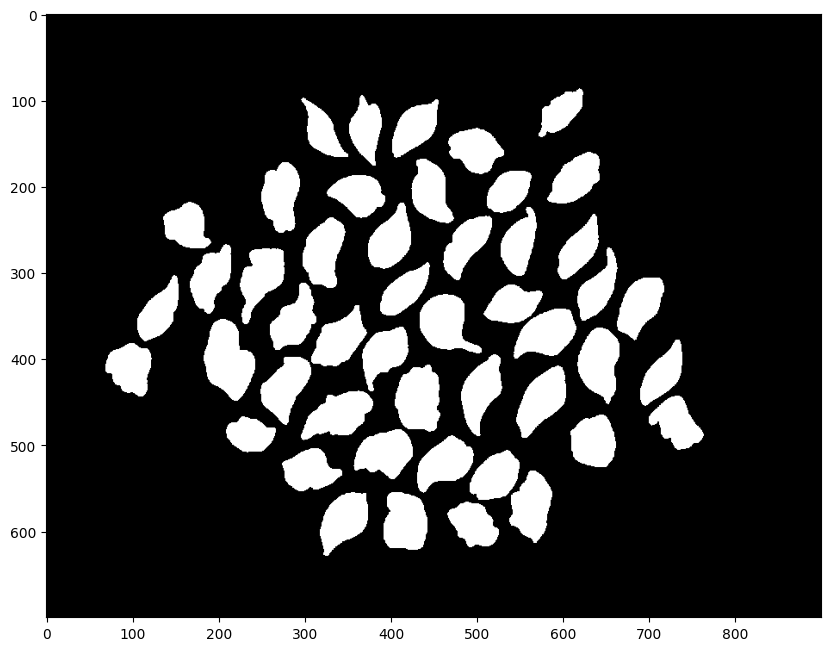

In [28]:
plt.figure(figsize=(10, 10))
plt.imshow(leaf_binary[300:1000, 1400:2300], cmap='grey')

## Tutupan Area

In [29]:
area_occupancy = getAreaOccupancy(leaf_binary, back_binary)

print(f"Area Occupancy: {area_occupancy*100:.2f}%")

Area Occupancy: 45.62%


## Dinamika Ruang Kosong

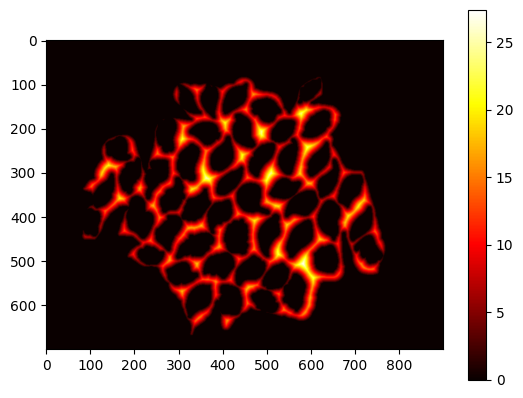

In [30]:
void_distance = cv2.distanceTransform(~(leaf_binary | ~back_binary), cv2.DIST_L2, 5)

plt.imshow(void_distance[300:1000, 1400:2300])
plt.colorbar()

DATA SUMMARY of [Void Distances]:
Num     : 139275
Mean    : 6.8649
SD      : 4.6168
SD rel  : 67.25%
Median  : 6.0000
MAD     : 3.1969
MAD rel : 53.28%
Min     : 1.0000
Max     : 27.3969



{'num': 139275,
 'mean': 6.8649206,
 'sd': 4.6168146,
 'median': 6.0,
 'mad': 3.1968994,
 'min': 1.0,
 'max': 27.396894}

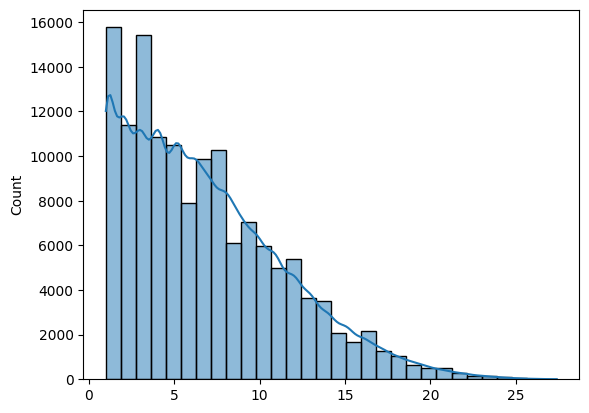

In [31]:
sns.histplot(void_distance[void_distance > 0], kde=True, bins=30)

summarizeData(void_distance[void_distance > 0], "Void Distances")

## Kesebangunan & Kongruensi

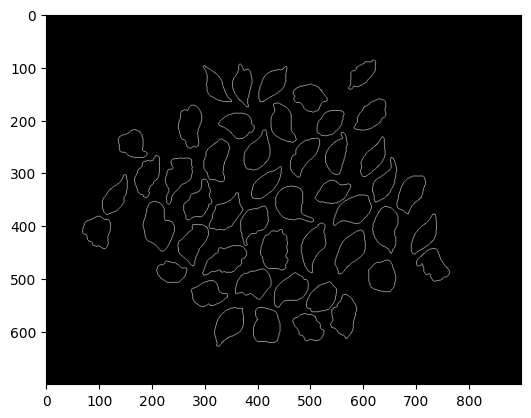

In [32]:
leaf_contour = extractContours(leaf_binary)
leaf_contour_map = createContourMap(leaf_binary.shape, leaf_contour)

plt.imshow(leaf_contour_map[300:1000, 1400:2300], cmap='grey')

In [33]:
leaf_contour_interpolated = interpolateContours(leaf_contour, 100)
leaf_mean_shape, leaf_contours_aligned = processGPA(leaf_contour_interpolated)

2.2786096887005285e-06


In [34]:
leaf_procrustes_distances = procrustesDistances(leaf_mean_shape, leaf_contours_aligned)
summarizeData(leaf_procrustes_distances, "Procrustes Analysis")

leaf_procrustes_distances

DATA SUMMARY of [Procrustes Analysis]:
Num     : 48
Mean    : 0.1185
SD      : 0.0381
SD rel  : 32.16%
Median  : 0.1157
MAD     : 0.0234
MAD rel : 20.25%
Min     : 0.0535
Max     : 0.2008



array([0.12927149, 0.13819475, 0.05347201, 0.09966378, 0.10939817,
       0.13888891, 0.07856718, 0.13646084, 0.1036883 , 0.20079841,
       0.18507477, 0.09203283, 0.08811608, 0.12027065, 0.11531903,
       0.1367654 , 0.1933199 , 0.13519622, 0.06943738, 0.09793644,
       0.09318069, 0.09105361, 0.07033394, 0.17159069, 0.09696498,
       0.09014898, 0.07316766, 0.12137303, 0.11602198, 0.15618352,
       0.1909168 , 0.10239269, 0.1111404 , 0.13120902, 0.13221465,
       0.14175475, 0.06709207, 0.18408552, 0.12546995, 0.0793907 ,
       0.07850847, 0.08620096, 0.06103825, 0.16219465, 0.10034509,
       0.19379713, 0.11893542, 0.12021565])

<Axes: ylabel='Count'>

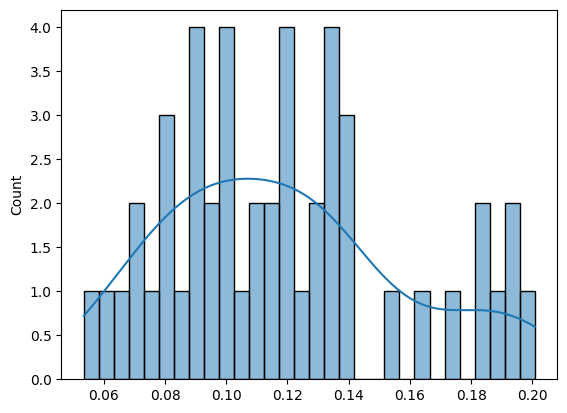

In [35]:
sns.histplot(leaf_procrustes_distances, kde=True, bins=30)

In [36]:
leaf_contour_areas = contourAreas(leaf_contour)
summarizeData(np.sqrt(leaf_contour_areas), "Big Variant Rooted Areas")

# leaf_contour_areas

DATA SUMMARY of [Big Variant Rooted Areas]:
Num     : 48
Mean    : 48.1118
SD      : 4.1861
SD rel  : 8.70%
Median  : 47.8147
MAD     : 3.1269
MAD rel : 6.54%
Min     : 39.5854
Max     : 60.1290



{'num': 48,
 'mean': 48.11182239765728,
 'sd': 4.186093514198722,
 'median': 47.81470887321909,
 'mad': 3.12691168454511,
 'min': 39.585350825778974,
 'max': 60.12902793160721}

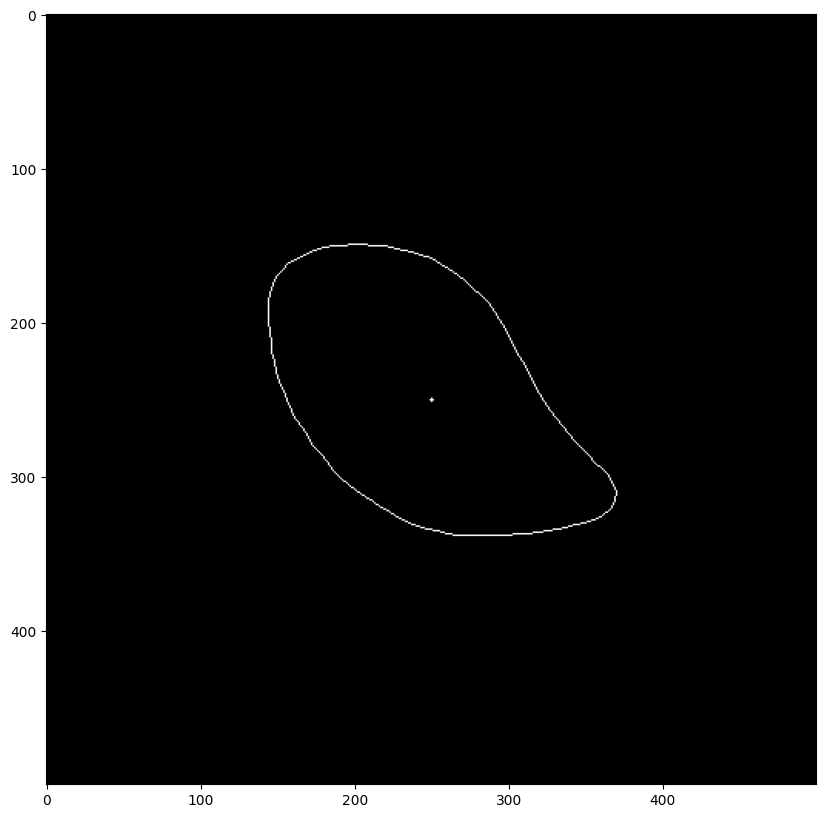

In [37]:
leaf_size_factor = 1000
plt.figure(figsize=(10, 10))

leaf_mean_shape_binary = drawStandardizedContour((500, 500), leaf_mean_shape, leaf_size_factor)

plt.imshow(leaf_mean_shape_binary, cmap='gray')

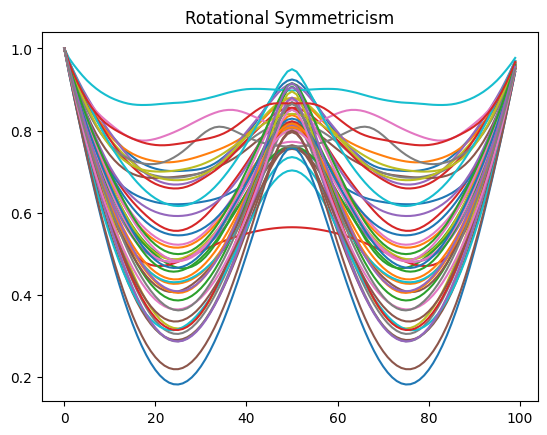

In [38]:
# plt.ylim((0.0, 1.0))
plt.title("Rotational Symmetricism")
for shape in leaf_contours_aligned:
    sns.lineplot(testRotationalSymmetry(shape))

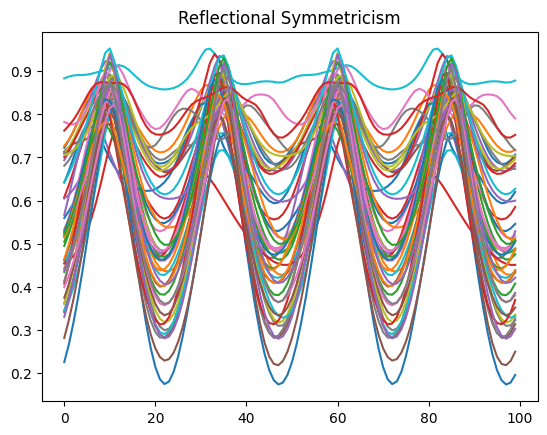

In [39]:
plt.title("Reflectional Symmetricism")
for shape in leaf_contours_aligned:
    sns.lineplot(testReflectionalSymmetry(shape))

<Axes: >

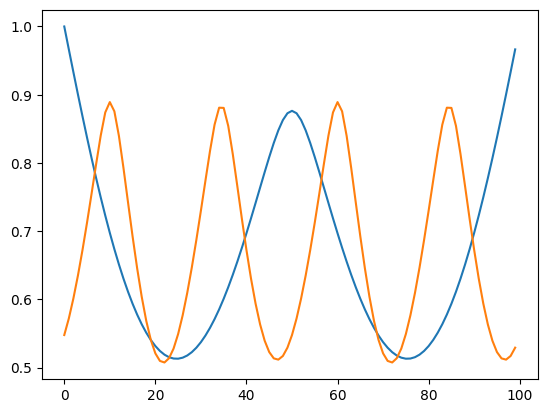

In [40]:
sns.lineplot(testRotationalSymmetry(leaf_mean_shape))
sns.lineplot(testReflectionalSymmetry(leaf_mean_shape))